PART#1 DATA COLLECTION

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cancer_df = pd.read_csv("brca.csv", index_col=0)  # drop first unnamed column
cancer_df.columns = [col.strip().replace('"','') for col in cancer_df.columns]  # clean quotes

PART#2 DATA PROCESSING

In [98]:
# showing first 5 rows
cancer_df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [99]:
# checking shape of dataset
cancer_df.shape

(569, 31)

In [100]:
# checking missing values
cancer_df.isnull().sum()

## Handling Missing Values

# No missing values were found in the dataset.Therefore, no handling (imputation/removal) was required.

x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

In [101]:
# checking duplicate values
cancer_df.duplicated().sum()

## Duplicate Check

#No duplicate rows were found in the dataset.

np.int64(0)

PART#3 NORMALIZATION

In [102]:

# Make a copy of original dataframe
cancer_log = cancer_df.copy()

# Select numeric columns for normalization (skip 'id' and 'diagnosis')
numeric_cols = cancer_log.select_dtypes(include=[np.number]).columns.tolist()

# Apply log2 normalization
cancer_log[numeric_cols] = np.log2(cancer_log[numeric_cols] + 1)

# Check the first 5 rows after normalization
cancer_log.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
1,3.861955,3.941106,6.466953,9.147968,0.134602,0.112754,0.093073,0.067377,0.249142,0.080876,...,4.340562,6.653920,9.476139,0.194087,0.235482,0.309176,0.174790,0.375957,0.101099,B
2,3.815575,4.062640,6.436795,9.025140,0.147307,0.172488,0.064441,0.044184,0.259062,0.095060,...,4.425594,6.601251,9.302639,0.177854,0.353436,0.249749,0.101421,0.398788,0.113474,B
3,3.392867,3.748461,5.938756,8.102763,0.140648,0.090745,0.042028,0.029644,0.240620,0.096329,...,4.058316,6.047233,8.303324,0.179384,0.156785,0.122567,0.087151,0.316146,0.107996,B
4,3.810443,4.279471,6.385604,9.035624,0.124103,0.053334,0.036496,0.041565,0.197488,0.082198,...,4.573496,6.417177,9.095133,0.133577,0.065145,0.068093,0.070568,0.261471,0.086363,B
5,3.201006,4.157044,5.720005,7.664625,0.119024,0.083288,0.022730,0.008511,0.234992,0.090894,...,4.521051,5.864434,7.925999,0.175940,0.183582,0.095992,0.036524,0.390117,0.103115,B


PART#4 VISUALIZATION

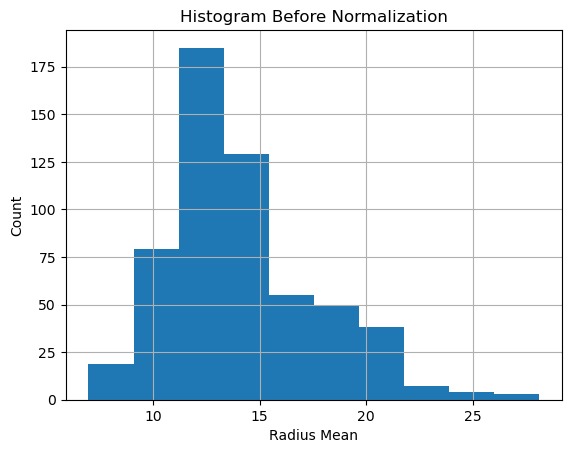

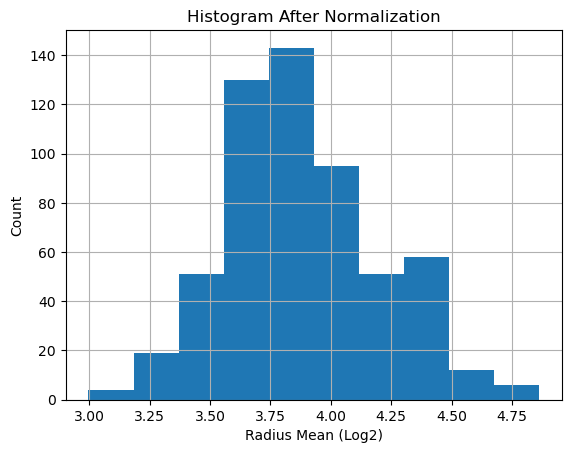

In [103]:

# Before normalization

## Use the column name
feature = 'x.radius_mean'  

# Before normalization
plt.figure()
cancer_df[feature].hist()
plt.xlabel("Radius Mean")
plt.ylabel("Count")
plt.title("Histogram Before Normalization")
plt.show()

# After normalization
plt.figure()
cancer_log[feature].hist()
plt.xlabel("Radius Mean (Log2)")
plt.ylabel("Count")
plt.title("Histogram After Normalization")
plt.show()

PART#5 EXPLORATORY DATA ANALYSIS(EDA)

In [104]:
#counting Malignant vs Benign
counts = cancer_df['y'].value_counts()

# Check distribution of target column
cancer_df['y'].value_counts()



y
B    357
M    212
Name: count, dtype: int64

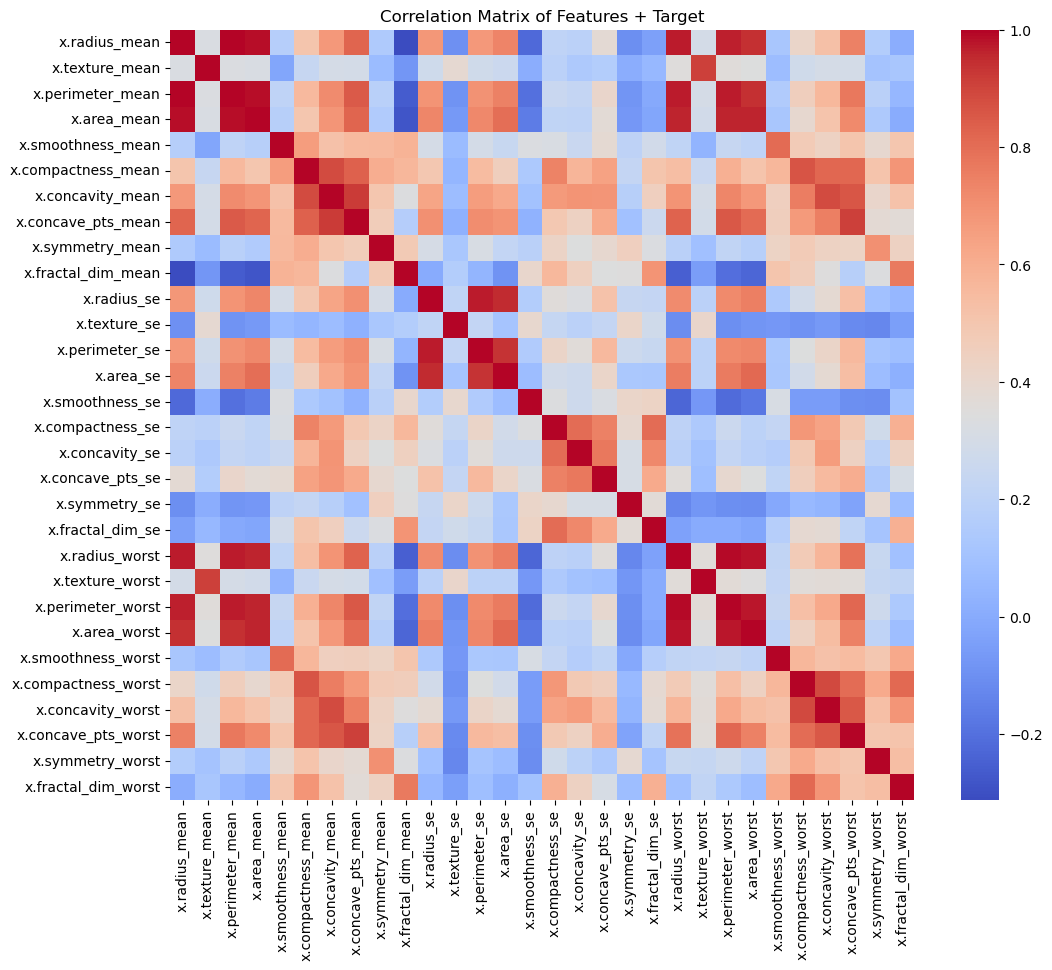

In [105]:
import seaborn as sns

# Compute correlation of all numeric columns
numeric_cols = cancer_df.select_dtypes(include=['number']).columns.tolist()
corr = cancer_df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of Features + Target')
plt.show()